# Notebook 01 — Data Collection

**Purpose:** Collect all raw datasets required for the Brooklyn urban analytics project, perform initial sanity checks, and assess the spatial coverage of OpenStreetMap POIs.

**Inputs:**
- `data/raw/pluto_25v4.csv` — NYC PLUTO 25v4 (all 5 boroughs)
- `data/raw/mta_subway_stations.csv` — MTA Subway Stations (downloaded from NY Open Data)
- `data/raw/osm_pois.geojson` — OpenStreetMap POIs produced by `src/fetch_pois.py` and the two rescue scripts (`src/fetch_failed_tiles.py`, `src/fetch_convenience.py`)

**Outputs:**
- `data/processed/brooklyn_pluto.parquet` — Brooklyn subset of PLUTO
- Spatial coverage diagnostic plots (in-notebook only)

**Downstream dependencies:** `02_data_cleaning.ipynb` consumes the Brooklyn PLUTO parquet.

**Author:** Delfin Aksu — Urban Building ML class project

## 1. Setup

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
# Project paths
PROJECT_ROOT = Path('..').resolve()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Project constants
PLUTO_VERSION = '25v4'
TARGET_BOROUGH = 'BK'  # Brooklyn (PLUTO uses 2-letter borough codes)

# Brooklyn approximate bounding box used for OSM fetching: (south, west, north, east)
BROOKLYN_BBOX = (40.55, -74.05, 40.74, -73.83)

# All 6 OSM categories are collected and (after rescue) usable downstream.
OSM_CATEGORIES = ['cafe', 'restaurant', 'school', 'park', 'supermarket', 'convenience']

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'PLUTO version: {PLUTO_VERSION}')

PROJECT_ROOT: C:\Users\Delfin AKSU\Desktop\urban-building-ml
PLUTO version: 25v4


## 2. NYC PLUTO Dataset

The Primary Land Use Tax Lot Output (PLUTO) dataset is published by the NYC Department of City Planning. It contains tax-lot-level records for every property in the five boroughs of NYC, including geometry centroids, building physical characteristics, land use, and assessed property values.

Version used: **PLUTO 25v4** (snapshot recorded for reproducibility).

### 2.1 Load the full dataset

In [3]:
pluto_path = RAW_DATA_DIR / f'pluto_{PLUTO_VERSION}.csv'
assert pluto_path.exists(), f'PLUTO file not found at {pluto_path}'

df = pd.read_csv(pluto_path, low_memory=False)
print(f'Loaded PLUTO {PLUTO_VERSION}: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded PLUTO 25v4: 858,644 rows x 92 columns


### 2.2 Borough distribution sanity check

In [4]:
borough_counts = df['borough'].value_counts()
borough_counts

borough
QN    324580
BK    276324
SI    125646
BX     89494
MN     42600
Name: count, dtype: int64

PLUTO uses two-letter borough codes:

- **MN** — Manhattan
- **BX** — Bronx
- **BK** — Brooklyn  ← *project target*
- **QN** — Queens
- **SI** — Staten Island

### 2.3 Filter to Brooklyn

In [5]:
brooklyn = df[df['borough'] == TARGET_BOROUGH].copy()
print(f'Brooklyn subset: {brooklyn.shape[0]:,} rows x {brooklyn.shape[1]} columns')
print(f'Retention rate: {brooklyn.shape[0] / df.shape[0]:.1%}')

Brooklyn subset: 276,324 rows x 92 columns
Retention rate: 32.2%


### 2.4 Save Brooklyn subset to processed data

In [6]:
brooklyn_path = PROCESSED_DATA_DIR / 'brooklyn_pluto.parquet'
brooklyn.to_parquet(brooklyn_path, index=False)
print(f'Saved Brooklyn PLUTO to: {brooklyn_path}')
print(f'File size: {brooklyn_path.stat().st_size / 1024**2:.1f} MB')

Saved Brooklyn PLUTO to: C:\Users\Delfin AKSU\Desktop\urban-building-ml\data\processed\brooklyn_pluto.parquet
File size: 22.3 MB


In [7]:
# Release the full PLUTO dataframe; downstream notebooks read brooklyn_pluto.parquet only
del df
import gc
gc.collect()

0

## 3. MTA Subway Stations

Source: [NY State Open Data — MTA Subway Stations](https://data.ny.gov/Transportation/MTA-Subway-Stations/39hk-dx4f).

This dataset provides the location and metadata for every subway station in the New York City Transit system. It will be used in Notebook 03 (Feature Engineering) to compute subway-accessibility features for every Brooklyn building.

In [8]:
mta_path = RAW_DATA_DIR / 'mta_subway_stations.csv'
assert mta_path.exists(), f'MTA file not found at {mta_path}'

mta = pd.read_csv(mta_path)
print(f'Loaded MTA stations: {mta.shape[0]} stations x {mta.shape[1]} columns')
mta.head()

Loaded MTA stations: 496 stations x 19 columns


,GTFS Stop ID,Station ID,Complex ID,Division,Line,Stop Name,Borough,CBD,Daytime Routes,Structure,GTFS Latitude,GTFS Longitude,North Direction Label,South Direction Label,ADA,ADA Northbound,ADA Southbound,ADA Notes,Georeference
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,False,N W,Elevated,40.775036,-73.912034,Last Stop,Manhattan,0,0,0,NaN,POINT (-73.912034 40.775036)
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,False,N W,Elevated,40.770258,-73.917843,Astoria,Manhattan,1,1,1,NaN,POINT (-73.917843 40.770258)
2,R04,3,3,BMT,Astoria,30 Av,Q,False,N W,Elevated,40.766779,-73.921479,Astoria,Manhattan,0,0,0,NaN,POINT (-73.921479 40.766779)
3,R05,4,4,BMT,Astoria,Broadway,Q,False,N W,Elevated,40.761820,-73.925508,Astoria,Manhattan,0,0,0,NaN,POINT (-73.925508 40.76182)
4,R06,5,5,BMT,Astoria,36 Av,Q,False,N W,Elevated,40.756804,-73.929575,Astoria,Manhattan,0,0,0,NaN,POINT (-73.929575 40.756804)


Note that the MTA file covers **all 5 boroughs**. Filtering to Brooklyn-relevant stations (including stations just outside Brooklyn that may still be the nearest to a Brooklyn building) is performed in Notebook 03 after the proper spatial-distance calculations are set up.

## 4. OpenStreetMap Points of Interest

POIs are fetched from the [Overpass API](https://overpass-api.de/) — a read-only API on top of OpenStreetMap. The fetching pipeline is implemented as three standalone scripts under `src/`:

1. `fetch_pois.py` — initial pass over all 6 categories x 16 tiles using the main Overpass endpoint.
2. `fetch_failed_tiles.py` — targeted rescue for the supermarket tiles that failed during the initial pass, using the Kumi Systems mirror as primary endpoint and the main endpoint as fallback.
3. `fetch_convenience.py` — full rescue for the convenience category (which failed across every tile in the initial pass), again with endpoint rotation.

Running fetch code as scripts rather than inline cells has two practical benefits: long-running fetches do not risk being interrupted by notebook state issues, and the same code paths can be re-executed independently when individual categories fail.

Categories collected:

| Category | OSM tag |
|---|---|
| cafe | `amenity=cafe` |
| restaurant | `amenity=restaurant` |
| school | `amenity=school` |
| park | `leisure=park` |
| supermarket | `shop=supermarket` |
| convenience | `shop=convenience` |

### 4.1 Overpass API connectivity test

In [9]:
overpass_url = 'https://overpass-api.de/api/interpreter'

test_query = '''
[out:json][timeout:25];
node["amenity"="cafe"](40.55,-74.05,40.74,-73.83);
out body 50;
'''

headers = {
    'User-Agent': 'urban-building-ml-student-project/1.0',
    'Accept': 'application/json'
}

response = requests.post(overpass_url, data={'data': test_query}, headers=headers, timeout=60)
print(f'Status: {response.status_code}')
print(f'Elements returned: {len(response.json()["elements"]) if response.status_code == 200 else "N/A"}')

Status: 200
Elements returned: 50


If the test returns `Status: 200` and a non-zero element count, the Overpass endpoint is reachable. The production fetch is then executed from the project root:

```bash
python src/fetch_pois.py            # initial full fetch
python src/fetch_failed_tiles.py    # supermarket rescue (7 northern tiles)
python src/fetch_convenience.py     # convenience rescue (all 16 tiles)
```

The combined output is written to `data/raw/osm_pois.geojson`.

### 4.2 Load fetched POIs

In [10]:
osm_path = RAW_DATA_DIR / 'osm_pois.geojson'
assert osm_path.exists(), f'OSM POIs not found at {osm_path}. Run src/fetch_pois.py first.'

with open(osm_path, 'r', encoding='utf-8') as f:
    osm_geo = json.load(f)

pois = pd.DataFrame([
    {
        'osm_id': feat['properties']['osm_id'],
        'category': feat['properties']['category'],
        'name': feat['properties'].get('name'),
        'lon': feat['geometry']['coordinates'][0],
        'lat': feat['geometry']['coordinates'][1],
    }
    for feat in osm_geo['features']
])

print(f'Loaded {len(pois):,} POIs across {pois["category"].nunique()} categories')

Loaded 8,980 POIs across 6 categories


### 4.3 Category-level summary

In [11]:
category_summary = pois['category'].value_counts().reindex(OSM_CATEGORIES, fill_value=0).to_frame('count')
category_summary['pct'] = (category_summary['count'] / category_summary['count'].sum() * 100).round(1)
category_summary

,count,pct
category,,
cafe,1439,16.0
restaurant,3858,43.0
school,788,8.8
park,780,8.7
supermarket,541,6.0
convenience,1574,17.5


## 5. Spatial Coverage Analysis

Raw category counts do not tell us whether the POIs are **spatially well-distributed** across Brooklyn. The fetch script processes the borough tile-by-tile (4×4 grid = 16 tiles). If individual tiles failed due to Overpass instability, those areas would appear artificially POI-poor — which would inject **spatial bias** into downstream feature engineering and modelling.

This section reproduces the tile geometry used by `src/fetch_pois.py` and counts how many POIs of each category fell into each tile. It serves both as the diagnostic that drove the two rescue passes and as the post-rescue verification that the final dataset has uniform spatial coverage.

### 5.1 Reconstruct the tile grid

In [12]:
def make_tiles(bbox, rows=4, cols=4):
    """Identical to make_tiles() in src/fetch_pois.py."""
    south, west, north, east = bbox
    lat_step = (north - south) / rows
    lon_step = (east - west) / cols
    tiles = []
    for i in range(rows):
        for j in range(cols):
            tiles.append({
                'index': i * cols + j + 1,
                'row': i, 'col': j,
                'south': south + i * lat_step,
                'north': south + (i + 1) * lat_step,
                'west':  west  + j * lon_step,
                'east':  west  + (j + 1) * lon_step,
            })
    return tiles

tiles = make_tiles(BROOKLYN_BBOX, rows=4, cols=4)
print(f'Reconstructed {len(tiles)} tiles')

Reconstructed 16 tiles


### 5.2 Count POIs per tile per category

In [13]:
def assign_tile(lat, lon, tiles):
    for t in tiles:
        if t['south'] <= lat <= t['north'] and t['west'] <= lon <= t['east']:
            return t['index']
    return None

pois['tile'] = pois.apply(lambda r: assign_tile(r['lat'], r['lon'], tiles), axis=1)

# Reindex BOTH axes so that the table always has 16 tiles x 6 categories,
# even if a category returned zero POIs across the whole borough.
tile_breakdown = (
    pois.groupby(['tile', 'category']).size()
        .unstack(fill_value=0)
        .reindex(index=range(1, 17), columns=OSM_CATEGORIES, fill_value=0)
)
tile_breakdown

category,cafe,restaurant,school,park,supermarket,convenience
tile,,,,,,
1,1,4,1,5,2,1
2,25,112,33,39,24,67
3,1,8,8,6,3,6
4,1,15,4,10,3,3
5,82,240,45,31,41,145
6,50,133,102,31,71,93
7,6,20,26,28,10,9
8,0,0,0,2,0,0
9,55,115,27,19,17,111


### 5.3 Visualise spatial coverage

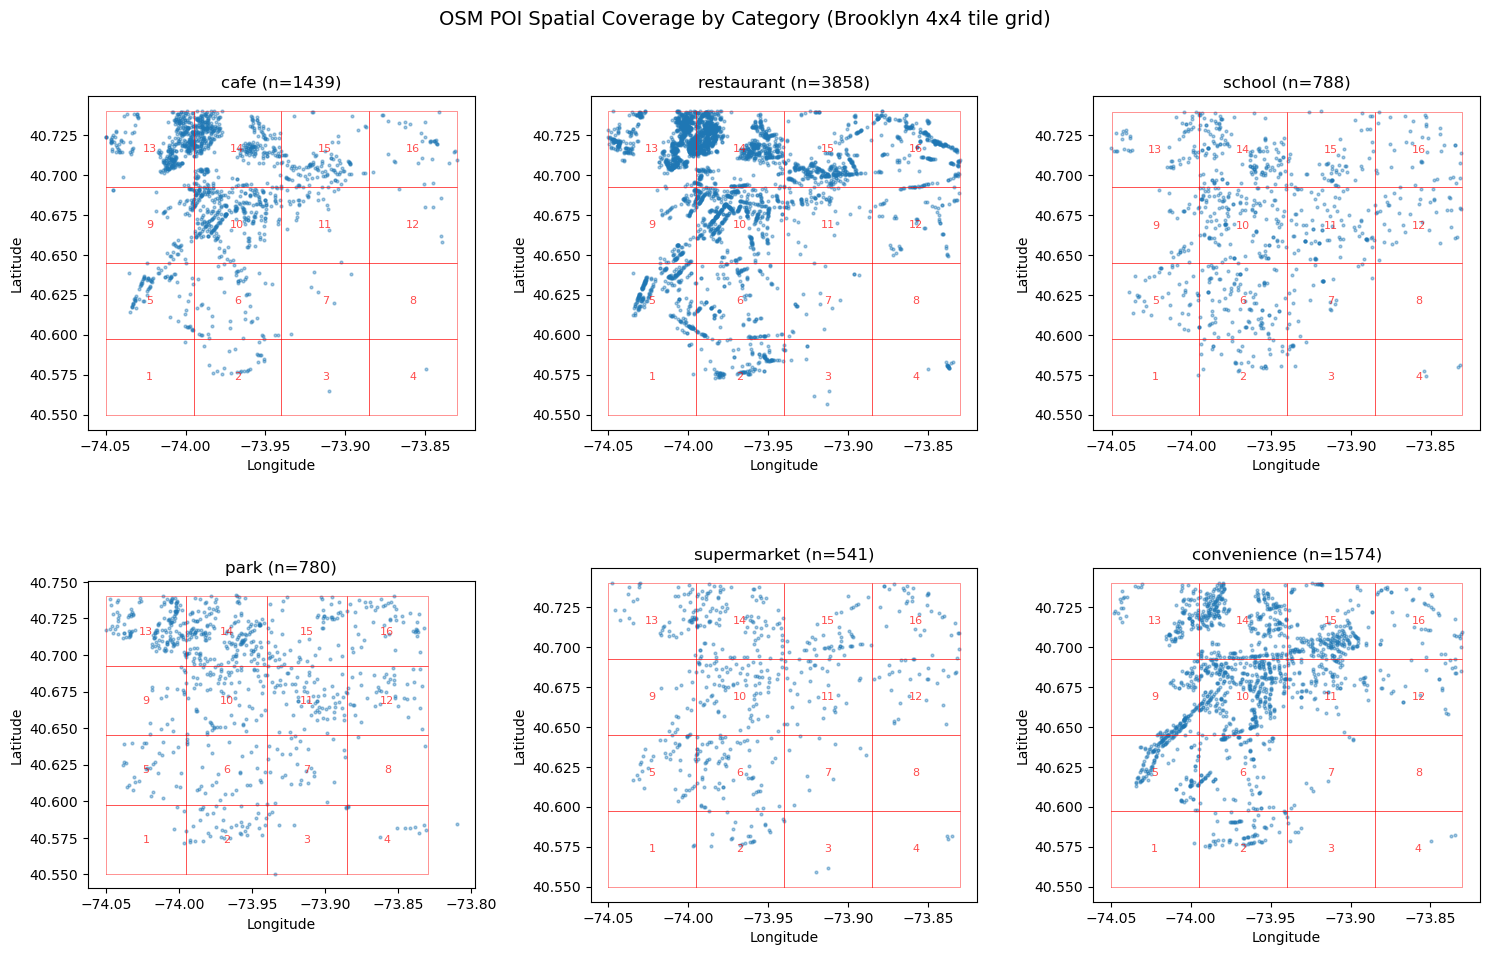

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, cat in zip(axes.flat, OSM_CATEGORIES):
    sub = pois[pois['category'] == cat]
    ax.scatter(sub['lon'], sub['lat'], s=4, alpha=0.4)

    # Overlay the tile grid
    for t in tiles:
        ax.plot(
            [t['west'], t['east'], t['east'], t['west'], t['west']],
            [t['south'], t['south'], t['north'], t['north'], t['south']],
            color='red', linewidth=0.5, alpha=0.6
        )
        ax.text(
            (t['west'] + t['east']) / 2,
            (t['south'] + t['north']) / 2,
            str(t['index']),
            ha='center', va='center', fontsize=8, color='red', alpha=0.7
        )

    ax.set_title(f'{cat} (n={len(sub)})')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

plt.suptitle('OSM POI Spatial Coverage by Category (Brooklyn 4x4 tile grid)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Identify failed tiles

A tile is flagged as **likely failed** if, for a given category, it has zero POIs while neighbouring activity (cafe + restaurant count in that same tile) is substantial. A tile that is empty in *every* category is more likely a legitimate empty region (water, parkland) rather than a fetch failure.

In [15]:
def diagnose_failures(category, min_neighbour_signal=30):
    """Heuristic: a tile is suspect if it has 0 POIs in `category`
    but its cafe+restaurant total >= min_neighbour_signal (proving the tile is populated).
    """
    if category not in tile_breakdown.columns:
        # Category column missing means zero POIs of this category anywhere in Brooklyn.
        # That is a total category failure, not tile-specific.
        return list(range(1, 17))

    failures = []
    for t in tiles:
        idx = t['index']
        cnt = tile_breakdown.loc[idx, category]
        food_signal = tile_breakdown.loc[idx, 'cafe'] + tile_breakdown.loc[idx, 'restaurant']
        if cnt == 0 and food_signal >= min_neighbour_signal:
            failures.append(idx)
    return failures

for cat in OSM_CATEGORIES:
    failed = diagnose_failures(cat)
    total = int(tile_breakdown[cat].sum())
    print(f'{cat:15s}: total={total:>6}  |  suspect tiles ({len(failed)}): {failed}')

cafe           : total=  1439  |  suspect tiles (0): []
restaurant     : total=  3858  |  suspect tiles (0): []
school         : total=   786  |  suspect tiles (0): []
park           : total=   774  |  suspect tiles (0): []
supermarket    : total=   541  |  suspect tiles (0): []
convenience    : total=  1574  |  suspect tiles (0): []


### 5.5 Coverage history and final state

**Initial fetch (`src/fetch_pois.py`):**

- `cafe`, `restaurant`, `school`, `park` — fully successful across all 16 tiles.
- `supermarket` — failed in **tiles 10–16** (the entire northern half of Brooklyn: Williamsburg, DUMBO, Park Slope, Bed-Stuy, Bushwick). This was a spatially-clustered failure pattern that would have introduced severe bias if left uncorrected.
- `convenience` — failed in **all 16 tiles** (zero retrieved). Effectively unavailable from the main Overpass endpoint.

**Rescue results:**

| Rescue script | Target | New POIs added | Tile success rate |
|---|---|---|---|
| `fetch_failed_tiles.py` | supermarket × 7 northern tiles | **+370** | 7 / 7 |
| `fetch_convenience.py` | convenience × all 16 tiles | **+1,574** | 16 / 16 |

Both rescues used the same strategy — Kumi Systems mirror as primary endpoint, main Overpass endpoint as fallback, exponential back-off between attempts. The Kumi mirror handled the load cleanly; only two tiles required a second attempt against the same endpoint, and the fallback endpoint was never invoked.

**Final coverage assessment:**

- All 6 categories are now available across the full Brooklyn bounding box.
- Tile 8 (south-eastern corner) is legitimately POI-poor across every category because it is dominated by Jamaica Bay and Floyd Bennett Field — water and parkland rather than residential or commercial fabric. It does not require further action.
- The OSM POI dataset is considered complete for downstream feature engineering.

## 6. Rescue Pipeline Reference

This section documents how the rescue scripts are invoked. They have already been executed and their outputs are included in `data/raw/osm_pois.geojson`, so this section is for reproducibility / audit purposes.

### 6.1 Supermarket rescue

```bash
python src/fetch_failed_tiles.py
```

Targets only tiles 10–16 for the `supermarket` category. Uses the Kumi Systems mirror first, the main Overpass endpoint as fallback. Deduplicates against the existing GeoJSON on `(osm_id, category)`.

### 6.2 Convenience rescue

```bash
python src/fetch_convenience.py
```

Targets all 16 tiles for the `convenience` category, using the same endpoint-rotation strategy as the supermarket rescue.

### 6.3 Post-rescue verification

In [16]:
# Confirm the file on disk reflects all three fetch passes
with open(osm_path, 'r', encoding='utf-8') as f:
    osm_geo_v2 = json.load(f)

pois_v2 = pd.DataFrame([
    {
        'category': feat['properties']['category'],
        'lon': feat['geometry']['coordinates'][0],
        'lat': feat['geometry']['coordinates'][1],
    }
    for feat in osm_geo_v2['features']
])
pois_v2['tile'] = pois_v2.apply(lambda r: assign_tile(r['lat'], r['lon'], tiles), axis=1)

per_tile = (
    pois_v2.groupby(['tile', 'category']).size()
        .unstack(fill_value=0)
        .reindex(index=range(1, 17), columns=OSM_CATEGORIES, fill_value=0)
)
print('Final POI counts per tile:')
print(per_tile)
print(f'\nGrand total: {len(pois_v2):,} POIs')

Final POI counts per tile:
category  cafe  restaurant  school  park  supermarket  convenience
tile                                                              
1            1           4       1     5            2            1
2           25         112      33    39           24           67
3            1           8       8     6            3            6
4            1          15       4    10            3            3
5           82         240      45    31           41          145
6           50         133     102    31           71           93
7            6          20      26    28           10            9
8            0           0       0     2            0            0
9           55         115      27    19           17          111
10         314         511     136    71           77          367
11          31          66      79    71           33           90
12           6          63      40    41           28           28
13         339         952      55 

## 7. Final Raw Data Inventory

| Source | File | Records | Notes |
|---|---|---|---|
| NYC PLUTO 25v4 | `data/raw/pluto_25v4.csv` | 858,644 (5 boroughs) | Snapshot version 25v4 |
| Brooklyn subset | `data/processed/brooklyn_pluto.parquet` | 276,324 | Filtered borough==`BK` |
| MTA Subway Stations | `data/raw/mta_subway_stations.csv` | 496 stations | All 5 boroughs (filtered later) |
| OSM POIs (final) | `data/raw/osm_pois.geojson` | 8,980 features | 6 categories, all tiles covered after two rescue passes |

**Data-engineering note for the report:** The OSM portion of the dataset required two follow-up rescue passes after the initial fetch. The root cause was transient instability of the main Overpass endpoint, not a problem with the query design. Rotating to the Kumi Systems mirror recovered every previously-failed tile on the first or second attempt. This pattern — initial fetch + diagnostic + targeted rescue — is documented as a deliberate part of the data engineering pipeline in `02_data_cleaning.ipynb` and the final report.

Proceed to **`02_data_cleaning.ipynb`**.